# LIAR Dataset — Data Exploration
**Purpose:** Understand the dataset before training — text lengths, label distributions, and whether our `max_length=250` setting makes sense.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from transformers import DistilBertTokenizer
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#cccccc',
    'xtick.color': '#999999',
    'ytick.color': '#999999',
    'text.color': '#cccccc',
    'grid.color': '#2a2a2a',
    'grid.linestyle': '--',
    'font.family': 'monospace',
    'axes.titlecolor': '#ffffff',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

REAL_COLOR = '#4fc3f7'   # Blue for Real
FAKE_COLOR = '#ef5350'   # Red for Fake
ALL_COLOR  = '#b39ddb'   # Purple for combined

print('Libraries loaded.')

Libraries loaded.


## 1. Load Processed Data

In [4]:
train_df = pd.read_csv('../data/LIAR/data/processed/train.csv')
val_df   = pd.read_csv('../data/LIAR/data/processed/val.csv')
test_df  = pd.read_csv('../data/LIAR/data/processed/test.csv')

# Combined for full picture
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,} | Total: {len(full_df):,}')
print(f'\nColumns: {list(full_df.columns)}')
full_df.head(5)

Train: 4,110 | Val: 511 | Test: 517 | Total: 5,138

Columns: ['text', 'label', 'original_label']


,text,label,original_label
0,Says the Annies List political group supports ...,1,0
1,When did the decline of coal start? It started...,0,1
2,Health care reform legislation is likely to ma...,1,0
3,The economic turnaround started at the end of ...,0,1
4,"""I'm the only person on this stage who has wor...",0,1


## 2. Label Distribution

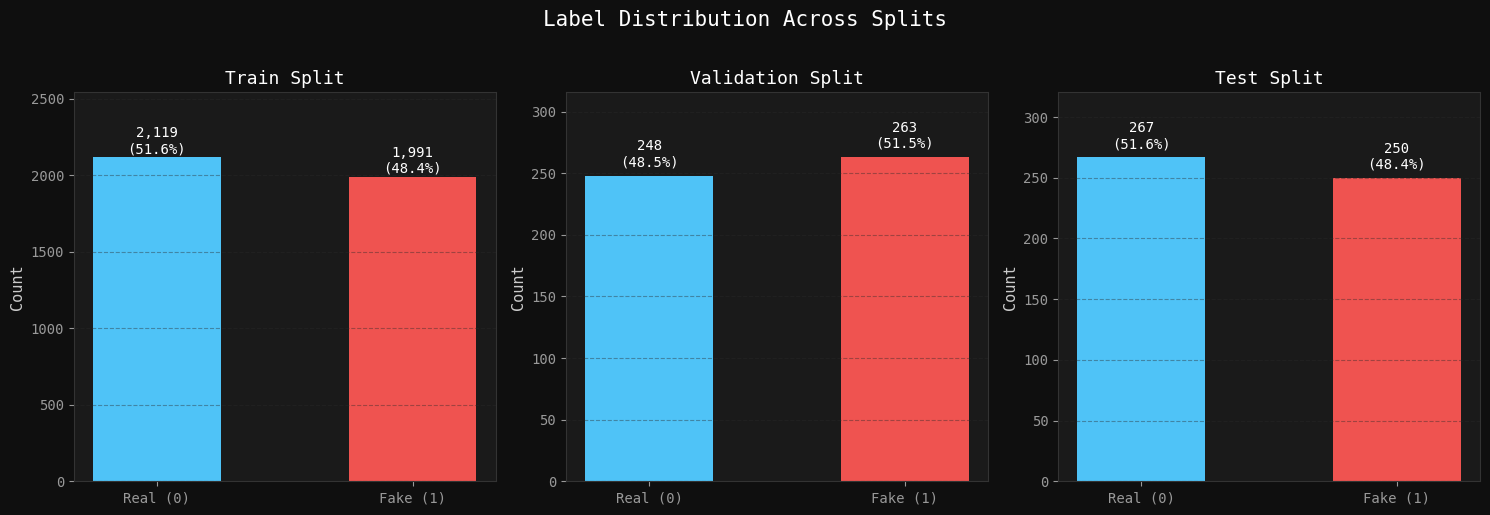

Saved to data/LIAR/results/evaluation/label_distribution.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Label Distribution Across Splits', fontsize=15, color='white', y=1.02)

splits     = [train_df, val_df, test_df]
split_names = ['Train', 'Validation', 'Test']

for ax, df, name in zip(axes, splits, split_names):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(
        ['Real (0)', 'Fake (1)'],
        counts.values,
        color=[REAL_COLOR, FAKE_COLOR],
        width=0.5,
        edgecolor='none'
    )
    # Value labels on bars
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, color='white'
        )
    ax.set_title(f'{name} Split', color='white')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.4)
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.tight_layout()
plt.savefig('../data/LIAR/results/evaluation/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/LIAR/results/evaluation/label_distribution.png')

## 3. Character Length Distribution
How long are the raw text entries in characters?

Character Length Statistics:
---------------------------------------------
  Overall  | mean=106 | median=99 | max=344
  Real (0) | mean=112 | median=105 | max=327
  Fake (1) | mean=100 | median=93 | max=344


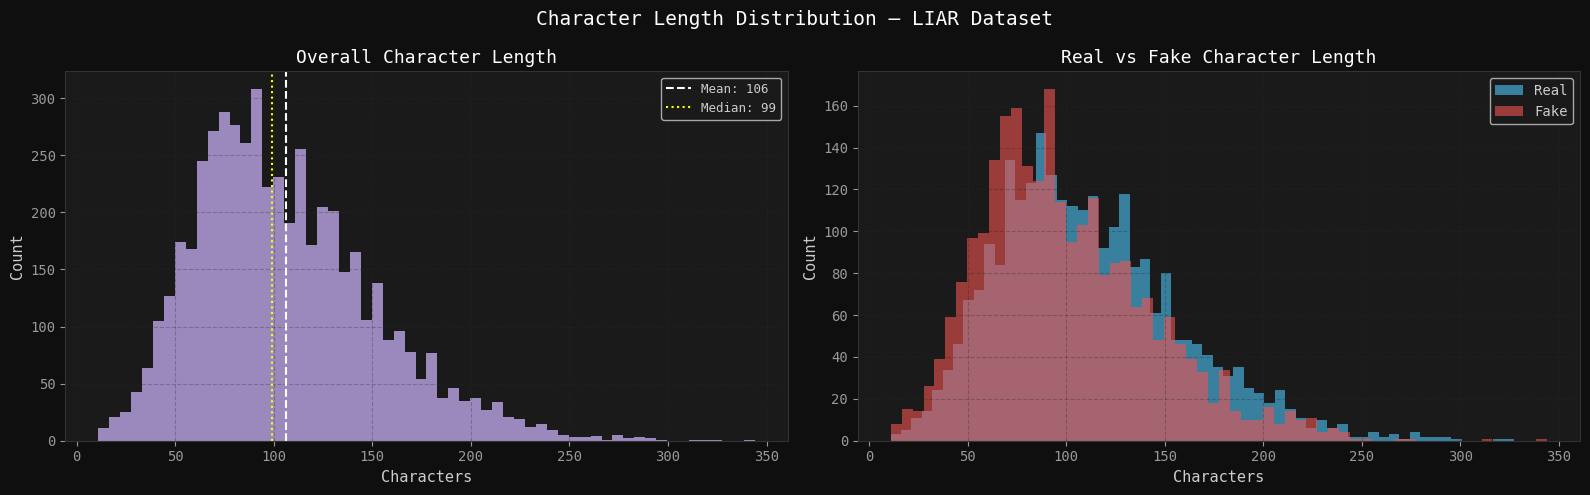

In [15]:
# Compute character lengths
full_df['char_length'] = full_df['text'].str.len()
real_df = full_df[full_df['label'] == 0]
fake_df = full_df[full_df['label'] == 1]

print('Character Length Statistics:')
print('-' * 45)
print(f'  Overall  | mean={full_df["char_length"].mean():.0f} | median={full_df["char_length"].median():.0f} | max={full_df["char_length"].max()}')
print(f'  Real (0) | mean={real_df["char_length"].mean():.0f} | median={real_df["char_length"].median():.0f} | max={real_df["char_length"].max()}')
print(f'  Fake (1) | mean={fake_df["char_length"].mean():.0f} | median={fake_df["char_length"].median():.0f} | max={fake_df["char_length"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Character Length Distribution — LIAR Dataset', fontsize=14, color='white')

# Left: Overall histogram
ax = axes[0]
ax.hist(full_df['char_length'], bins=60, color=ALL_COLOR, alpha=0.85, edgecolor='none')
ax.axvline(full_df['char_length'].mean(),   color='white',  linestyle='--', linewidth=1.5, label=f'Mean: {full_df["char_length"].mean():.0f}')
ax.axvline(full_df['char_length'].median(), color='yellow', linestyle=':',  linewidth=1.5, label=f'Median: {full_df["char_length"].median():.0f}')
ax.set_title('Overall Character Length')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: Real vs Fake overlay
ax = axes[1]
ax.hist(real_df['char_length'], bins=60, color=REAL_COLOR, alpha=0.6, label='Real', edgecolor='none')
ax.hist(fake_df['char_length'], bins=60, color=FAKE_COLOR, alpha=0.6, label='Fake', edgecolor='none')
ax.set_title('Real vs Fake Character Length')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/LIAR/results/evaluation/char_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Token Length Distribution
This is what actually matters for DistilBERT — how many **tokens** does each entry produce?
We want to verify our `max_length=250` captures most entries without truncation.

In [7]:
print('Loading DistilBERT tokenizer...')
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

print('Tokenizing all entries (this may take ~30 seconds)...')
full_df['token_length'] = full_df['text'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
)

real_df = full_df[full_df['label'] == 0]
fake_df = full_df[full_df['label'] == 1]

MAX_LENGTH = 250
truncated = (full_df['token_length'] > MAX_LENGTH).sum()
pct_truncated = truncated / len(full_df) * 100

print('\nToken Length Statistics:')
print('-' * 50)
print(f'  Overall  | mean={full_df["token_length"].mean():.1f} | median={full_df["token_length"].median():.0f} | max={full_df["token_length"].max()}')
print(f'  Real (0) | mean={real_df["token_length"].mean():.1f} | median={real_df["token_length"].median():.0f} | max={real_df["token_length"].max()}')
print(f'  Fake (1) | mean={fake_df["token_length"].mean():.1f} | median={fake_df["token_length"].median():.0f} | max={fake_df["token_length"].max()}')
print(f'\n  Entries exceeding max_length={MAX_LENGTH}: {truncated} ({pct_truncated:.1f}%)')

Loading DistilBERT tokenizer...
Tokenizing all entries (this may take ~30 seconds)...

Token Length Statistics:
--------------------------------------------------
  Overall  | mean=24.1 | median=23 | max=79
  Real (0) | mean=25.3 | median=24 | max=77
  Fake (1) | mean=22.9 | median=22 | max=79

  Entries exceeding max_length=250: 0 (0.0%)


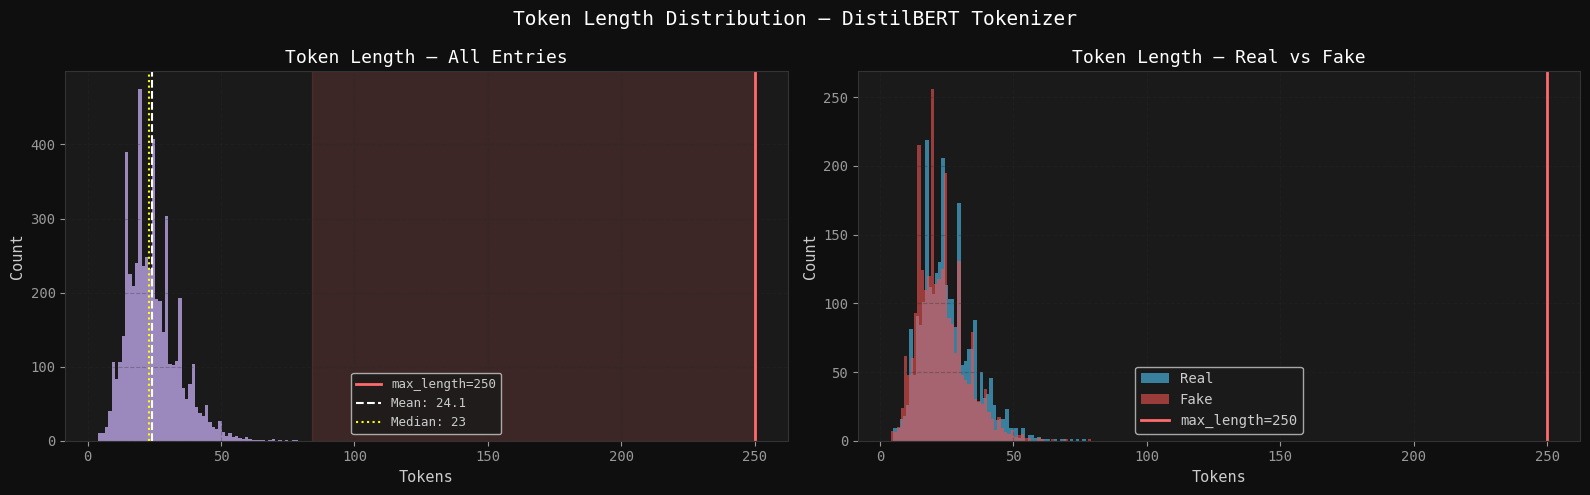

Saved token length plot.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Token Length Distribution — DistilBERT Tokenizer', fontsize=14, color='white')

# Left: Overall with max_length line
ax = axes[0]
ax.hist(full_df['token_length'], bins=60, color=ALL_COLOR, alpha=0.85, edgecolor='none')
ax.axvline(MAX_LENGTH,                       color='#ff6b6b', linestyle='-',  linewidth=2,   label=f'max_length={MAX_LENGTH}')
ax.axvline(full_df['token_length'].mean(),   color='white',   linestyle='--', linewidth=1.5, label=f'Mean: {full_df["token_length"].mean():.1f}')
ax.axvline(full_df['token_length'].median(), color='yellow',  linestyle=':',  linewidth=1.5, label=f'Median: {full_df["token_length"].median():.0f}')
ax.set_title('Token Length — All Entries')
ax.set_xlabel('Tokens')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Shade truncated region
ax.axvspan(MAX_LENGTH, full_df['token_length'].max() + 5,
           alpha=0.15, color='#ff6b6b', label='Truncated region')

# Right: Real vs Fake overlay
ax = axes[1]
ax.hist(real_df['token_length'], bins=60, color=REAL_COLOR, alpha=0.6, label='Real', edgecolor='none')
ax.hist(fake_df['token_length'], bins=60, color=FAKE_COLOR, alpha=0.6, label='Fake', edgecolor='none')
ax.axvline(MAX_LENGTH, color='#ff6b6b', linestyle='-', linewidth=2, label=f'max_length={MAX_LENGTH}')
ax.set_title('Token Length — Real vs Fake')
ax.set_xlabel('Tokens')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/LIAR/results/evaluation/token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved token length plot.')

## 5. Percentile Analysis — What max_length should we use?

In [9]:
percentiles = [50, 75, 90, 95, 99, 100]
print('Token length percentiles:')
print('-' * 35)
for p in percentiles:
    val = np.percentile(full_df['token_length'], p)
    covered = (full_df['token_length'] <= val).sum()
    print(f'  p{p:>3}: {val:>5.0f} tokens  ({covered/len(full_df)*100:.1f}% of data covered)')

print(f'\nCurrent setting: max_length={MAX_LENGTH}')
covered_pct = (full_df['token_length'] <= MAX_LENGTH).sum() / len(full_df) * 100
print(f'Coverage at max_length={MAX_LENGTH}: {covered_pct:.1f}% of all entries')

# Recommendation
p95 = int(np.percentile(full_df['token_length'], 95))
p99 = int(np.percentile(full_df['token_length'], 99))
print(f'\nRecommendation:')
print(f'  Conservative (95% coverage): max_length={p95}')
print(f'  Thorough     (99% coverage): max_length={p99}')

Token length percentiles:
-----------------------------------
  p 50:    23 tokens  (54.0% of data covered)
  p 75:    29 tokens  (75.4% of data covered)
  p 90:    37 tokens  (90.4% of data covered)
  p 95:    42 tokens  (95.5% of data covered)
  p 99:    52 tokens  (99.0% of data covered)
  p100:    79 tokens  (100.0% of data covered)

Current setting: max_length=250
Coverage at max_length=250: 100.0% of all entries

Recommendation:
  Conservative (95% coverage): max_length=42
  Thorough     (99% coverage): max_length=51


## 6. Original 6-Class Label Distribution
How many samples were dropped when we removed `half-true`?

Loading original LIAR dataset for 6-class comparison...


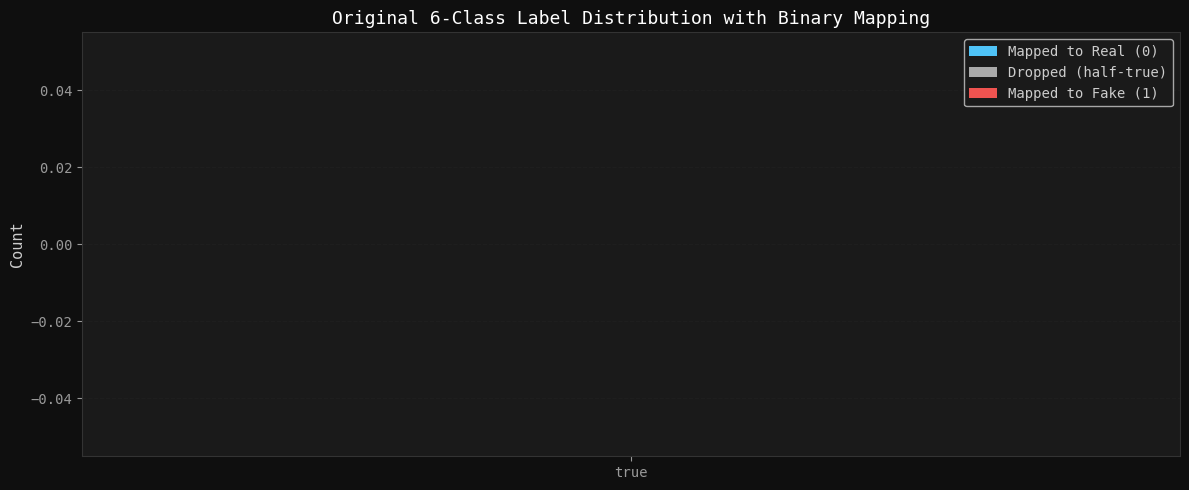

Dropped nan half-true samples (nan% of original dataset)


In [10]:
from datasets import load_dataset

print('Loading original LIAR dataset for 6-class comparison...')
raw = load_dataset('liar')
raw_all = [ex['label'] for split in ['train', 'validation', 'test'] for ex in raw[split]]
raw_series = pd.Series(raw_all)

order = ['true', 'mostly-true', 'half-true', 'barely-true', 'false', 'pants-fire']
counts = raw_series.value_counts().reindex(order)

colors = [REAL_COLOR, REAL_COLOR, '#aaaaaa', FAKE_COLOR, FAKE_COLOR, FAKE_COLOR]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(order, counts.values, color=colors, edgecolor='none', width=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{val:,}',
        ha='center', va='bottom', fontsize=10, color='white'
    )

# Annotate half-true as dropped
half_true_idx = order.index('half-true')
ax.text(
    half_true_idx, counts['half-true'] / 2,
    'DROPPED\n(ambiguous)',
    ha='center', va='center', fontsize=9,
    color='black', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#aaaaaa', alpha=0.9)
)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=REAL_COLOR, label='Mapped to Real (0)'),
    Patch(facecolor='#aaaaaa',  label='Dropped (half-true)'),
    Patch(facecolor=FAKE_COLOR, label='Mapped to Fake (1)'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')
ax.set_title('Original 6-Class Label Distribution with Binary Mapping', color='white')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/LIAR/results/evaluation/original_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

half_true_count = counts['half-true']
total = counts.sum()
print(f'Dropped {half_true_count} half-true samples ({half_true_count/total*100:.1f}% of original dataset)')

## 7. Sample Texts by Label
Sanity check — let's read some actual examples

In [11]:
pd.set_option('display.max_colwidth', 200)

print('=== REAL examples (label=0) ===')
display(full_df[full_df['label'] == 0][['text', 'original_label', 'token_length']].sample(5, random_state=42))

print('\n=== FAKE examples (label=1) ===')
display(full_df[full_df['label'] == 1][['text', 'original_label', 'token_length']].sample(5, random_state=42))

=== REAL examples (label=0) ===


,text,original_label,token_length
2167,"Tim Kaine doubled down in his support of devastating defense cuts, saying the the deal was the right thing to do.",1,26
2212,"""So far, the Recovery Act is responsible for the jobs of about 2 million Americans who would otherwise be unemployed. ... [And] the Recovery Act is on track to save or create another 1.5 million j...",1,51
1267,Van Jones signed a petition indicating he thinks the Bush administration blew up the World Trade Center and covered it up.,1,24
1430,"Says that according to many reports and even our own data, the state of Texas spent more through Medicaid on orthodontia than all other states combined.",1,35
849,"Sotomayor thinks ""that ones sex, race and ethnicity ought to affect the decisions one renders from the bench.""",1,27



=== FAKE examples (label=1) ===


,text,original_label,token_length
3782,Our kids cant openly celebrate Christmas or pray in school.,0,14
511,"On tax inversions, the Wall Street Journalsurprisingly attacked this tax scheme.",0,20
3302,"Says many local governments in Wisconsin already require employees to pay 20 percent, 30 percent or even 40 percent of their health insurance premiums.",0,29
827,"As we near the 10th anniversary of the 9/11 terrorist attacks, we should not forget that some of the hijackers used New Jersey drivers licenses to board those aircraft.",0,37
2775,Says Ken Cuccinelli attacked churches for helping the poor.,0,15


## 8. Summary
Key findings to inform training decisions.

In [12]:
print('=' * 55)
print('DATASET SUMMARY')
print('=' * 55)
print(f'  Total samples (after dropping half-true): {len(full_df):,}')
print(f'  Real (0): {(full_df["label"]==0).sum():,} ({(full_df["label"]==0).mean()*100:.1f}%)')
print(f'  Fake (1): {(full_df["label"]==1).sum():,} ({(full_df["label"]==1).mean()*100:.1f}%)')
print()
print(f'  Avg token length:    {full_df["token_length"].mean():.1f} tokens')
print(f'  Median token length: {full_df["token_length"].median():.0f} tokens')
print(f'  Max token length:    {full_df["token_length"].max()} tokens')
print()
covered = (full_df['token_length'] <= MAX_LENGTH).mean() * 100
print(f'  Coverage at max_length={MAX_LENGTH}: {covered:.1f}%')
print()
print('  Class balance:', 'GOOD (close to 50/50)' if abs((full_df['label']==0).mean() - 0.5) < 0.05 else 'IMBALANCED')
print('=' * 55)

DATASET SUMMARY
  Total samples (after dropping half-true): 5,138
  Real (0): 2,634 (51.3%)
  Fake (1): 2,504 (48.7%)

  Avg token length:    24.1 tokens
  Median token length: 23 tokens
  Max token length:    79 tokens

  Coverage at max_length=250: 100.0%

  Class balance: GOOD (close to 50/50)
